In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import time
# from kernels.squared_exponential import SquaredExponential
# from kernels.matern import Matern
from torch.optim import Adam

# import sys
import math
# sys.path.append('/Users/colecitrenbaum/Documents/GPs/gp-quadrature/Tests and Sanity Checks/')
from efgpnd import EFGPND
import warnings
# warnings.filterwarnings("ignore", message=".*disabling cuda.*")


In [2]:
data = np.load("/Users/colecitrenbaum/Downloads/001_data.npz")

In [3]:
kernel_type = "SquaredExponential"
from kernels.squared_exponential import SquaredExponential


In [4]:
x_raw = torch.tensor(data['coords'], dtype=torch.float64)
# x = x_raw
x_min = x_raw.min(dim=0).values
x_max = x_raw.max(dim=0).values
x = 2 * (x_raw - x_min) / (x_max - x_min) - 1
y = torch.tensor(data['log_vs'], dtype=torch.float64)
# x = x_raw - x_raw.mean(dim=0)
y = y - y.mean()


In [11]:

sigmasq = 0.1
EPSILON = 1e-4
subsample_indices = torch.randperm(x.shape[0])[:1_000]
x_subsample = x[subsample_indices]
y_subsample = y[subsample_indices]


max_iters = 50
J = 10

# Initialize training log
training_log = {
    'iter': [],
    'lengthscale': [],
    'variance': [],
    'sigmasq': [],
}

model = EFGPND(x, y, kernel=SquaredExponential(dimension=3, init_lengthscale=0.3, init_variance=1),sigmasq=sigmasq, eps=EPSILON,estimate_params=False)
# model = EFGPND(x, y, kernel="SquaredExponential",sigmasq=0.2 ,eps=EPSILON,estimate_params=True)
optimizer = Adam(model.parameters(), lr=0.1)

for it in range(max_iters):
    optimizer.zero_grad()
    if it > max_iters*0.8:
        t1 = time.time()
        model.compute_gradients(trace_samples=10,cg_tol=1e-5)
        t2 = time.time()
        # print(f"Time taken: {t2 - t1} seconds")
    else:
        t1 = time.time()
        model.compute_gradients(trace_samples=1,cg_tol=1e-5)
        t2 = time.time()


    optimizer.step() 

    print(f"Time taken: {t2 - t1} seconds")
    print(f'Kernel params: {model.kernel.lengthscale}, {model.kernel.variance},{model.sigmasq}')

    # Record current hyperparameters in the log
    lengthscale = model.kernel.get_hyper('lengthscale')
    variance = model.kernel.get_hyper('variance')
    sigmasq = model._gp_params.sig2.item()
    training_log['iter'].append(it)
    training_log['lengthscale'].append(lengthscale)
    training_log['variance'].append(variance)
    training_log['sigmasq'].append(sigmasq)

    if it % 10 == 0:
        print(f"[ε={EPSILON} | J={J}] iter {it:>3}  "
              f"ℓ={lengthscale:.4g}  "
              f"σ_f²={variance:.4g}  σ_n²={sigmasq:.4g}")

print(f'Final hyperparams: ℓ={lengthscale:.4g}, σ_f²={variance:.4g}, σ_n²={sigmasq:.4g}')





torch.Size([2197, 3])
CG Time taken: 3.838141918182373 seconds
3718
Time taken: 7.50396203994751 seconds
Kernel params: 0.27145122541079125, 1.1051709180752434,0.11051709180756455
[ε=0.0001 | J=10] iter   0  ℓ=0.2715  σ_f²=1.105  σ_n²=0.1105
torch.Size([3375, 3])
CG Time taken: 4.43027925491333 seconds
3862
Time taken: 7.871450185775757 seconds
Kernel params: 0.24564628528177104, 1.1227648399514303,0.12057040694675927
torch.Size([4913, 3])
CG Time taken: 30.95173716545105 seconds
3772
Time taken: 51.565402030944824 seconds
Kernel params: 0.22224411812930941, 1.1000245190502536,0.12734309337693006
torch.Size([4913, 3])
CG Time taken: 31.04245400428772 seconds
3641
Time taken: 51.57625079154968 seconds
Kernel params: 0.2013219745953833, 1.0639514682510567,0.12941407487464626
torch.Size([6859, 3])
CG Time taken: 31.422518014907837 seconds
3499
Time taken: 50.604546785354614 seconds
Kernel params: 0.18239917336075395, 1.0190815614877458,0.12773684071839236
torch.Size([9261, 3])
CG Time tak

KeyboardInterrupt: 

IndexError: list index out of range

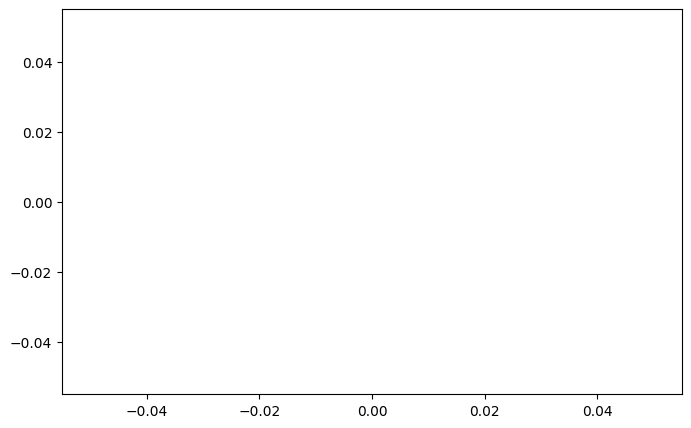

In [14]:
import matplotlib.pyplot as plt

# Plot lengthscale (x) vs variance (y) from training log
plt.figure(figsize=(8, 5))
plt.plot(training_log['lengthscale'], training_log['variance'], marker='o', label='Training Path')

# Mark the beginning
plt.scatter(training_log['lengthscale'][0], training_log['variance'][0], color='green', s=100, label='Start')
plt.annotate('Start', (training_log['lengthscale'][0], training_log['variance'][0]), 
             textcoords="offset points", xytext=(10,10), ha='left', color='green')

# Mark the end
plt.scatter(training_log['lengthscale'][-1], training_log['variance'][-1], color='red', s=100, label='End')
plt.annotate('End', (training_log['lengthscale'][-1], training_log['variance'][-1]), 
             textcoords="offset points", xytext=(10,-15), ha='left', color='red')

plt.xlabel('Lengthscale')
plt.ylabel('Variance')
plt.title('Training Log: Lengthscale vs Variance')
plt.legend()
plt.grid(True)
plt.show()


In [10]:
# random indices to subsample 

subsample_indices = torch.randperm(x.shape[0])[:500]
x_subsample = x[subsample_indices]
y_subsample = y[subsample_indices]
lengthscale_min = 0.00001
lengthscale_max = 5

variance_min = 0.001
variance_max = 1

lengthscales = torch.linspace(lengthscale_min, lengthscale_max, 50)
variances = torch.linspace(variance_min, variance_max, 50)
log_marginals_grid = torch.zeros((len(lengthscales), len(variances)))

# Calculate log marginal likelihood for each grid point
for i, lengthscale in enumerate(lengthscales):
    for j, variance in enumerate(variances):
        if kernel_type == 'SquaredExponential':
            kernel = SquaredExponential(dimension=3, init_lengthscale=lengthscale.item(), init_variance=variance.item())

        log_marginals_grid[i, j] = kernel.log_marginal(x_subsample, y_subsample, model.sigmasq)



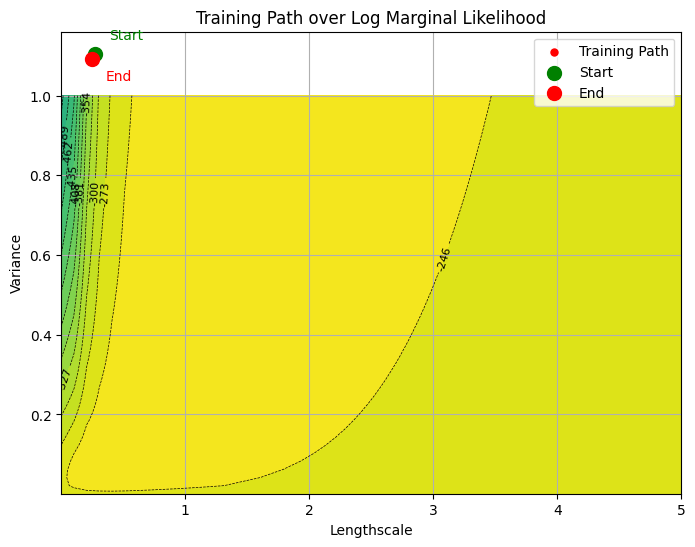

In [11]:

# Plot the training path (lengthscale, variance) over the log marginal likelihood grid

# For numerical stability, clip extremely low log marginal values if desired (optional)
# log_marginal_clipped = np.clip(log_marginals_grid, -100, log_marginals_grid.max())
log_marginal_clipped = log_marginals_grid  # No clipping for now

# Set up contour levels for filled and line contours
fill_levels = np.linspace(-1000, log_marginals_grid.max(), 30)
line_levels = np.linspace(-1000, log_marginals_grid.max(), 30)

# Convert training log lists to arrays for plotting
training_lengthscales_arr = np.array(training_log['lengthscale'])
training_variances_arr = np.array(training_log['variance'])

# Create a single plot
fig, ax = plt.subplots(figsize=(8, 6))

# Plot the filled contours of log marginal likelihood
cf = ax.contourf(lengthscales, variances, log_marginal_clipped.T,
                 levels=fill_levels, cmap='viridis', extend='both')
# Overlay contour lines
cs = ax.contour(lengthscales, variances, log_marginal_clipped.T,
                levels=line_levels, colors='k', linewidths=0.5)
ax.clabel(cs, inline=True, fontsize=8, fmt='%1.0f')

# Plot the training path
ax.scatter(training_lengthscales_arr, training_variances_arr,
           color='red', edgecolors='w', s=50, label='Training Path', zorder=10)
ax.plot(training_lengthscales_arr, training_variances_arr,
        color='red', linestyle='--', zorder=9)

# Mark the start and end points
ax.scatter(training_lengthscales_arr[0], training_variances_arr[0], color='green', s=100, label='Start', zorder=11)
ax.annotate('Start', (training_lengthscales_arr[0], training_variances_arr[0]), 
            textcoords="offset points", xytext=(10,10), ha='left', color='green')
ax.scatter(training_lengthscales_arr[-1], training_variances_arr[-1], color='red', s=100, label='End', zorder=12)
ax.annotate('End', (training_lengthscales_arr[-1], training_variances_arr[-1]), 
            textcoords="offset points", xytext=(10,-15), ha='left', color='red')

ax.set_xlabel('Lengthscale')
ax.set_ylabel('Variance')
ax.set_title('Training Path over Log Marginal Likelihood')
ax.legend(fontsize=10)
ax.grid(True)
plt.show()
